# Analisis de mercado y atraccion de estaciones del subte de CABA

Este notebook implementa los ejercicios 2 y 3 del trabajo practico reutilizando la red base ya construida en `analisis_conectividad_subte_caba.py`.

La idea es mantener el mismo flujo que el notebook anterior: una sola llamada genera tablas y figuras, y despues cada seccion muestra los resultados mas utiles para discutir el mercado potencial, la atraccion urbana y los cambios en los flujos OD.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from analisis_mercado_atraccion_subte_caba import generate_outputs

BASE_DIR = Path.cwd()
FIGURES_DIR = BASE_DIR / 'figures'

DEMAND_RADIUS_M = 800
POI_RADIUS_M = 400
D0_MINUTES = 15.0

results = generate_outputs(
    demand_radius_m=DEMAND_RADIUS_M,
    poi_radius_m=POI_RADIUS_M,
    decay_minutes=D0_MINUTES,
)

config = results['config']
diagnostics = results['diagnostics']
mapping_diagnostics = results['mapping_diagnostics']
correlations = results['correlations']
model_summary = results['model_summary']
top_demand = results['top_demand']
top_attraction = results['top_attraction']
top_betweenness_demand = results['top_betweenness_demand']
top_betweenness_attraction = results['top_betweenness_attraction']
station_metrics = results['station_metrics']

## 1. Supuestos y chequeos

Antes de mirar los resultados conviene dejar explicitadas tres decisiones metodologicas:

- la demanda potencial se mide con radios censales a menos de `800 m` de cada estacion,
- la atraccion se mide con puntos de interes de OpenStreetMap a menos de `400 m`,
- la comparacion con molinetes usa el tramo previo al ASPO de 2020 para evitar el sesgo mas fuerte de la pandemia.

Tambien hay un detalle de integracion de fuentes: la base de molinetes trae `Echeverria`, pero la red base disponible en el proyecto no incluye esa estacion; en sentido inverso, la red tiene `Plaza de Mayo`, que no aparece en el archivo resumido de molinetes usado aca.

In [2]:
config

,parametro,valor
0,radio_demanda_m,800
1,radio_poi_m,400
2,d0_minutos,15.0
3,molinetes_periodo,2020-01-01 a 2020-03-19


In [3]:
diagnostics

,indicador,valor
0,estaciones_red,89
1,estaciones_con_molinetes_matcheadas,88
2,estaciones_red_sin_molinetes,1
3,estaciones_molinetes_sin_red,1
4,radios_censales,3554
5,poi_educacion_descargados,3039
6,poi_salud_descargados,1456
7,poi_comercio_descargados,5004


In [4]:
display(mapping_diagnostics['turnstiles_without_network_station'])
display(mapping_diagnostics['stations_without_turnstiles'])

,linea,estacion_molinetes
0,B,Echeverria


,linea,estacion_red
0,A,Plaza de Mayo


## 2. Ejercicio 2: mercado potencial de cada estacion

El mapa siguiente resume la demanda potencial `D_i` de cada estacion a partir de la poblacion censal cercana. El tamano y el color de cada nodo crecen cuando la estacion captura mas poblacion residente dentro del radio elegido.

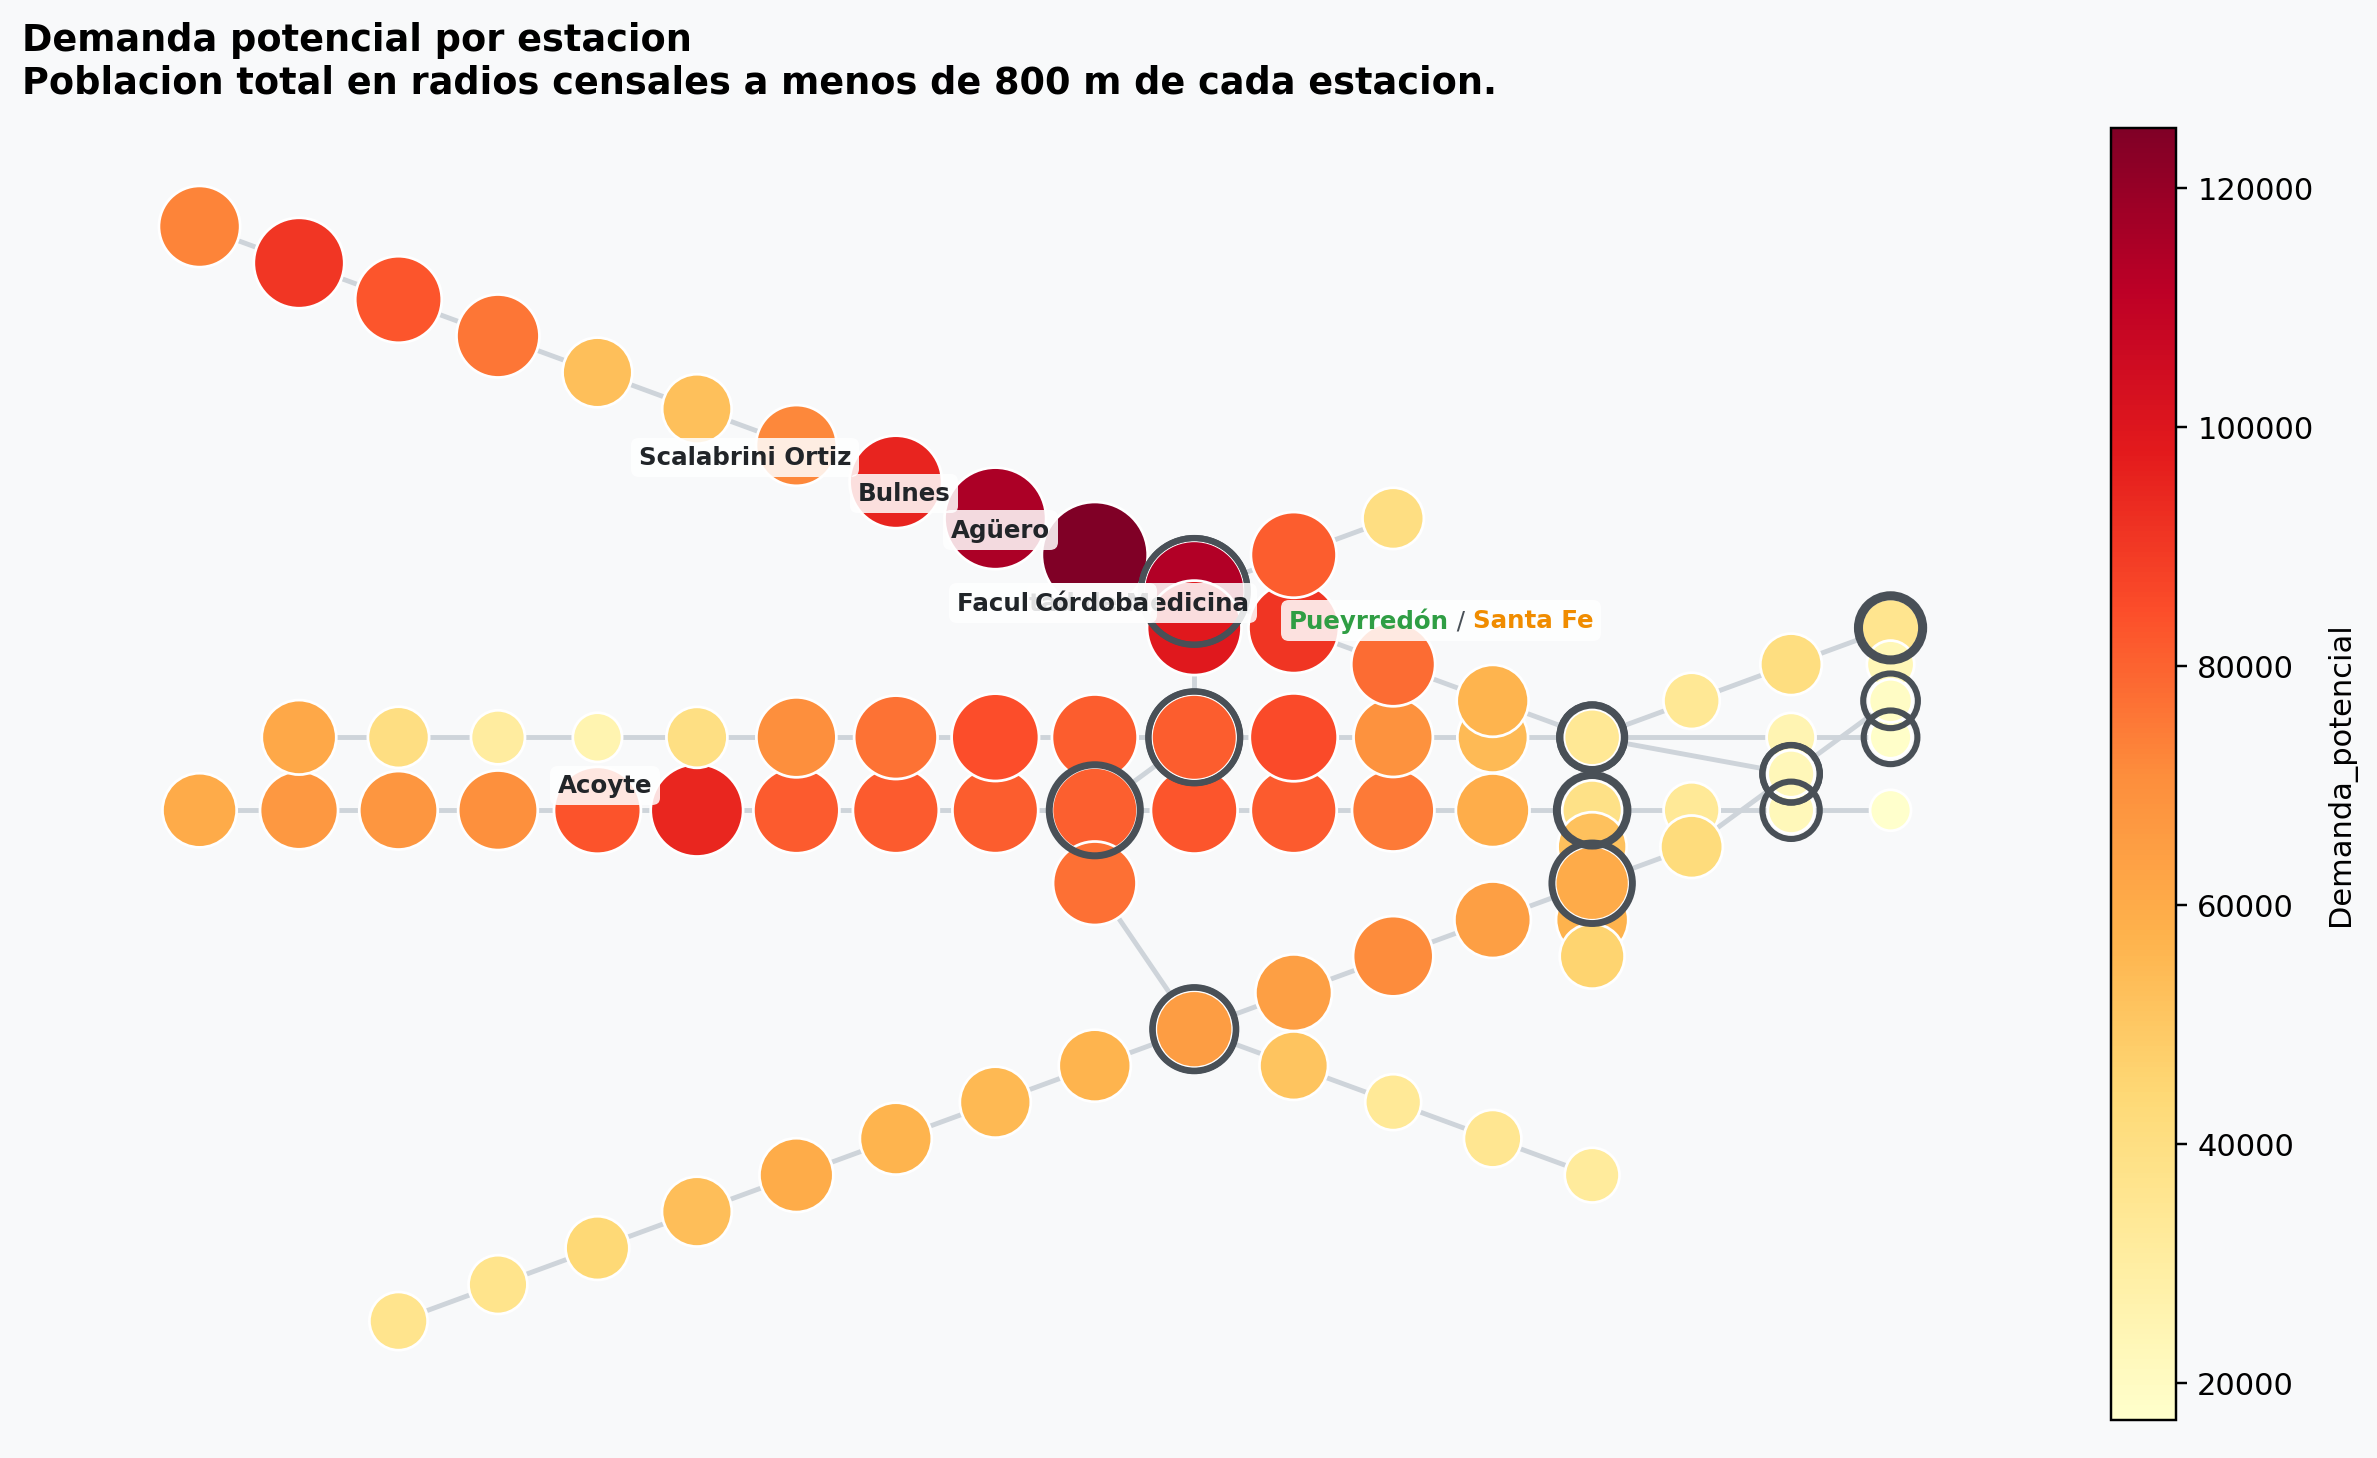

In [ ]:
display(Image(filename=str(FIGURES_DIR / 'demanda_potencial_por_estacion.png')))
# prbar grafico enre real dividido potencial

In [6]:
top_demand

,estacion,linea,demanda_potencial,pasajeros_diarios_promedio,radios_cubiertos
31,Agüero,D,125052,7992.333333,148
45,Bulnes,D,115091,2236.520000,141
10,Pueyrredón,D,114579,1348.407407,138
8,Santa Fe,H,114052,1811.185185,137
11,Córdoba,H,99144,5106.666667,127
54,Scalabrini Ortiz,D,95064,4653.333333,123
62,Acoyte,A,94821,1878.200000,111
26,Facultad de Medicina,D,90884,1966.629630,123
83,Juramento,D,90745,2445.925926,124
19,Pasteur,B,85589,8147.333333,119


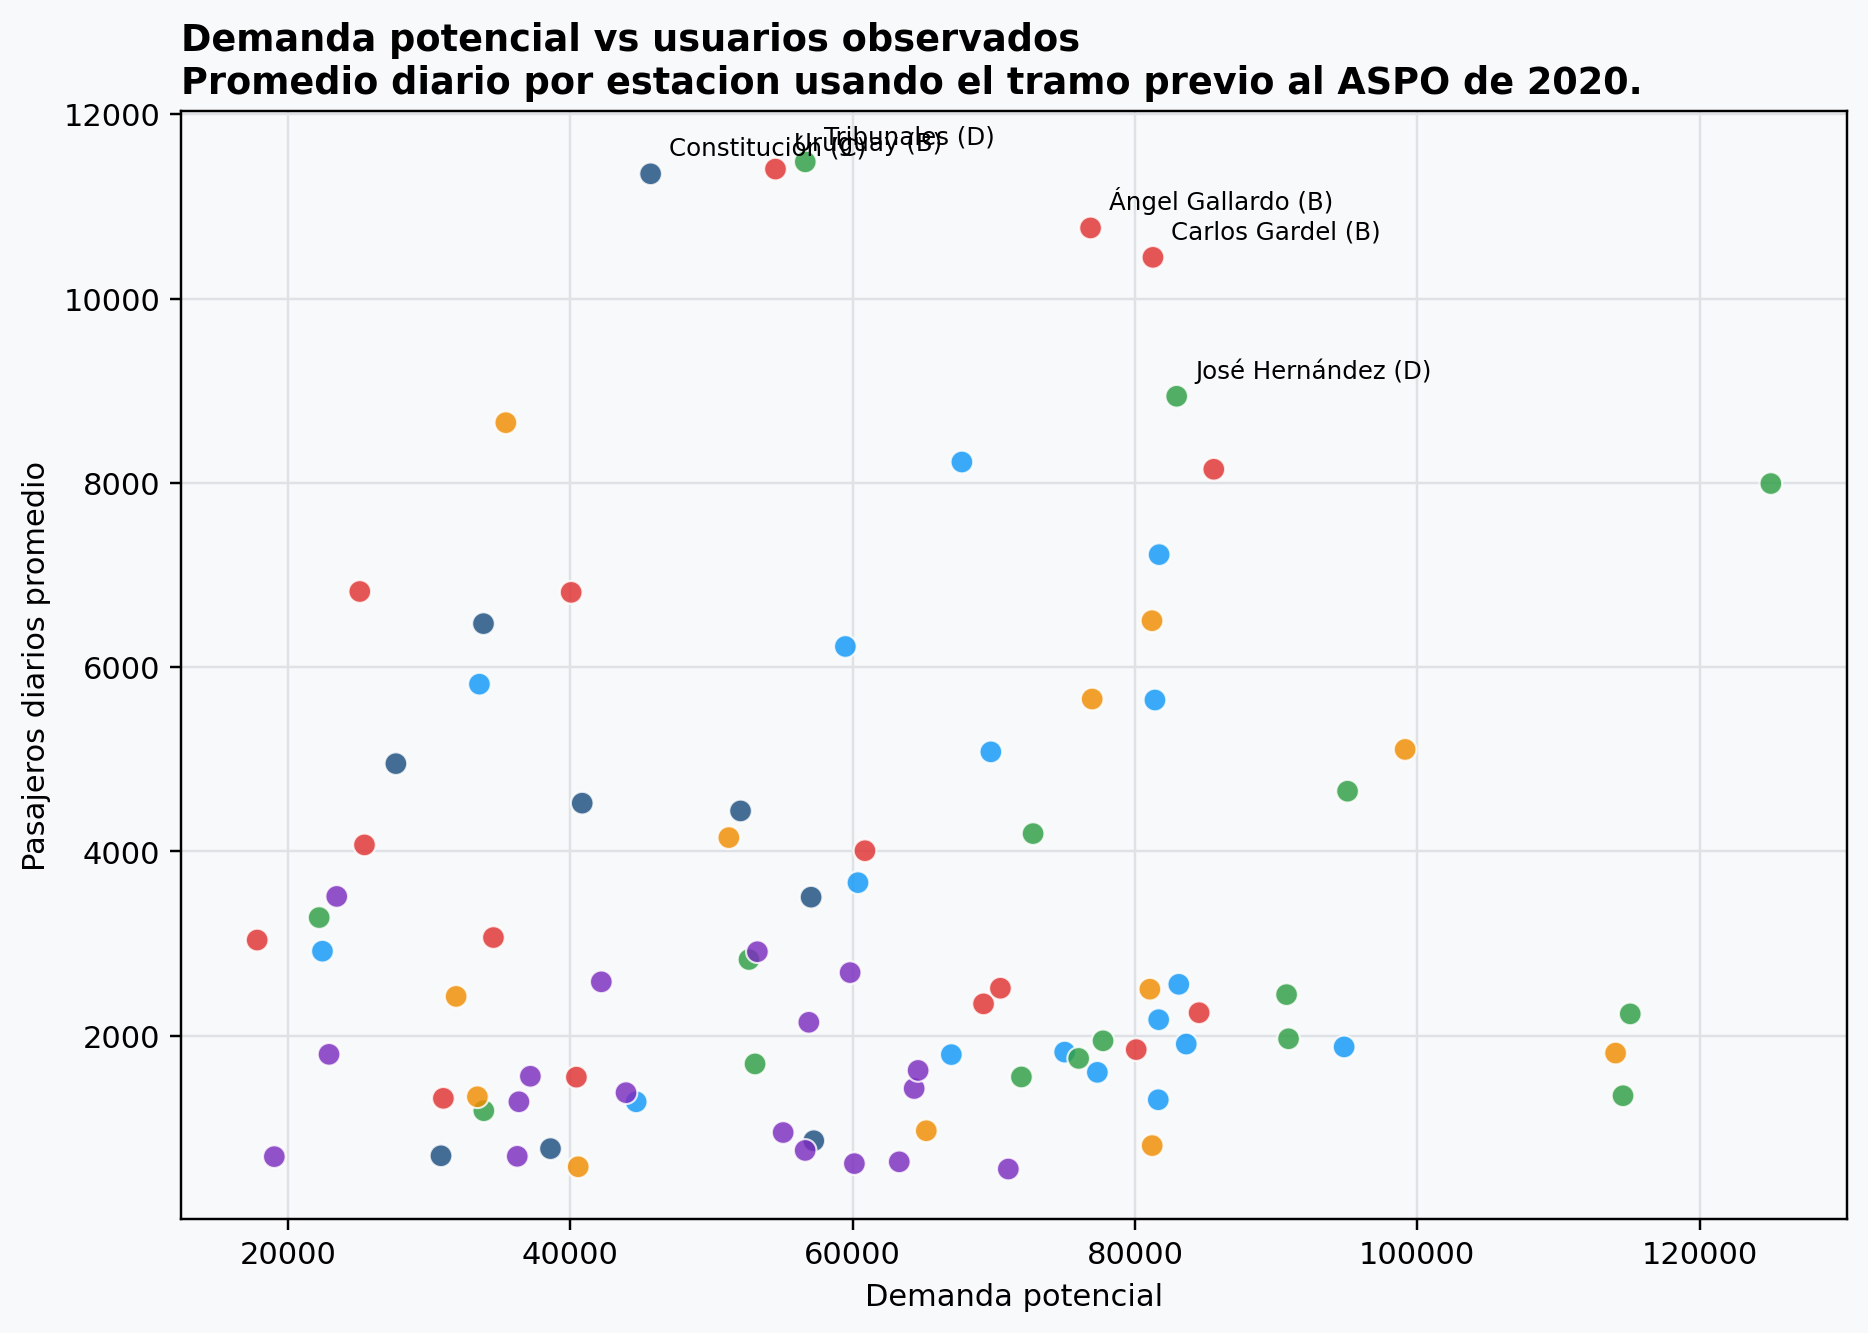

,comparacion,pearson,spearman
0,demanda_vs_molinetes,0.085444,0.102127


In [ ]:
display(Image(filename=str(FIGURES_DIR / 'demanda_vs_molinetes.png')))
correlations[correlations['comparacion'] == 'demanda_vs_molinetes']
# mirar con escala log log
# mirar tambien atraccion con amenities

### Modelo OD con demanda

Para el modelo de gravedad del ejercicio 2 se usa

`P(i->j) = C * D_i * D_j * exp(-d_ij / d0)`

con `d0 = 15 min`. La tabla compara el escenario sin peso con el escenario ponderado por demanda. Debajo aparece el ranking de estaciones con mayor betweenness bajo ese modelo de flujos.

In [ ]:
model_summary.iloc[:2]

In [ ]:
top_betweenness_demand

## 3. Ejercicio 3: atraccion de cada estacion

Se eligieron tres conjuntos de puntos de interes para caracterizar la atraccion urbana inmediata de cada estacion:

- educacion,
- salud,
- comercio.

Cada mapa muestra cuantos POI de esa categoria quedan dentro de `400 m` de la estacion.

In [ ]:
display(Image(filename=str(FIGURES_DIR / 'poi_educacion_por_estacion.png')))
display(Image(filename=str(FIGURES_DIR / 'poi_salud_por_estacion.png')))
display(Image(filename=str(FIGURES_DIR / 'poi_comercio_por_estacion.png')))

In [ ]:
display(Image(filename=str(FIGURES_DIR / 'atraccion_total_por_estacion.png')))
top_attraction

In [ ]:
display(Image(filename=str(FIGURES_DIR / 'atraccion_vs_molinetes.png')))
correlations[correlations['comparacion'] == 'atraccion_vs_molinetes']

### Modelo OD con demanda y atraccion

En el segundo modelo de gravedad se reemplaza la masa de destino por la atraccion observada alrededor de la estacion:

`P'(i->j) = C * D_i * O_j * exp(-d_ij / d0)`

La tabla final resume los tres escenarios y el ranking muestra que estaciones concentran mas intermediacion cuando el destino depende de la atraccion urbana y no solo de la poblacion residente.

In [ ]:
model_summary

In [ ]:
top_betweenness_attraction